In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [2]:
df = pd.read_csv(r"C:\Minor Projects\Minor Project 6th sem\Dataset\loan_data.csv")
print(df.shape)
print(df.head(3))

(45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561   
1                 0.08                         2.0           504   
2                 0.44                         3.0           635   

  previous_loan_defaults_on_file  loan_status  
0                             No            1  
1                            Yes         

In [3]:
display(df.head(3))

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [5]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [6]:
display(df.describe())

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
# display(df.describe(include="category"))

In [8]:
display(df.duplicated().sum())

np.int64(0)

In [9]:
df['person_gender'] = df['person_gender'].map({'female':0, 'male':1})

In [10]:
print(df['person_education'].unique(),'\n')
print(df['person_home_ownership'].unique(),'\n')
print(df['loan_intent'].unique(),'\n')
print(df['previous_loan_defaults_on_file'].unique())

<StringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str 

<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str 

<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str 

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [11]:
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No':0, 'Yes':1})

In [12]:
display(df.head())

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,1,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  int64  
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [14]:
df['person_age']=df['person_age'].astype('int')

In [15]:
# change some data type for memory save   
df['person_education'] = df['person_education'].astype('category')
df['person_home_ownership'] = df['person_home_ownership'].astype('category')
df['loan_intent'] = df['loan_intent'].astype('category')


In [16]:
df.rename(columns= {'cb_person_cred_hist_length':'credit_history_length'}, inplace=True)

In [17]:
df['loan_to_income_ratio'] = df['loan_amnt']/ df['person_income']

In [18]:
df['age_group'] = pd.cut(df['person_age'],
                        bins=[17, 25, 35, 45, 60, 150],
                        labels=['18-25', '26-35', '36-45', '46-60', '60+'])

In [19]:
income_bins=[0, 30000, 60000, 100000, np.inf]
income_labels=['Low(<30k)', 'Medium(30-60k)', 'High(60-100k)', 'Very High(>100k)']
df['income_group'] = pd.cut(df['person_income'], bins=income_bins, labels=income_labels)

In [20]:
credit_bins = [0, 588, 670, 740, 800, 850]
credit_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
df['credit_category'] = pd.cut(df['credit_score'],
                              bins=credit_bins,
                              labels=credit_labels)

In [21]:
print("\nColumn Names:")
for i, cols in enumerate(df.columns, 1):
    print(f"{i:2}. {cols}")


Column Names:
 1. person_age
 2. person_gender
 3. person_education
 4. person_income
 5. person_emp_exp
 6. person_home_ownership
 7. loan_amnt
 8. loan_intent
 9. loan_int_rate
10. loan_percent_income
11. credit_history_length
12. credit_score
13. previous_loan_defaults_on_file
14. loan_status
15. loan_to_income_ratio
16. age_group
17. income_group
18. credit_category


In [22]:
print("\nTarget Variable Distribution (Loan_Status):")
loan_status_counts = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

print(f"Approved (1): {loan_status_counts[1]:,} loans ({loan_status_percent[1]:.2f}%)")
print(f'Rejected (0): {loan_status_counts[0]:,} loans ({loan_status_percent[0]:.2f}%)')
print(f"Total {len(df):,} loans")


Target Variable Distribution (Loan_Status):
Approved (1): 10,000 loans (22.22%)
Rejected (0): 35,000 loans (77.78%)
Total 45,000 loans


In [23]:
print('\nCategorical Variable Distribution')
categorical_columns = df.select_dtypes(include=['category']).columns

for cols in categorical_columns:
    print(f"\n{cols}:")
    value_counts = df[cols].value_counts()
    for value, counts in value_counts.items():
        percentage = (counts / len(df)) * 100
        print(f"  {value}: {counts:,} ({percentage:.1f}%) ")


Categorical Variable Distribution

person_education:
  Bachelor: 13,399 (29.8%) 
  Associate: 12,028 (26.7%) 
  High School: 11,972 (26.6%) 
  Master: 6,980 (15.5%) 
  Doctorate: 621 (1.4%) 

person_home_ownership:
  RENT: 23,443 (52.1%) 
  MORTGAGE: 18,489 (41.1%) 
  OWN: 2,951 (6.6%) 
  OTHER: 117 (0.3%) 

loan_intent:
  EDUCATION: 9,153 (20.3%) 
  MEDICAL: 8,548 (19.0%) 
  VENTURE: 7,819 (17.4%) 
  PERSONAL: 7,552 (16.8%) 
  DEBTCONSOLIDATION: 7,145 (15.9%) 
  HOMEIMPROVEMENT: 4,783 (10.6%) 

age_group:
  18-25: 20,441 (45.4%) 
  26-35: 20,073 (44.6%) 
  36-45: 3,724 (8.3%) 
  46-60: 684 (1.5%) 
  60+: 78 (0.2%) 

income_group:
  High(60-100k): 16,690 (37.1%) 
  Medium(30-60k): 15,383 (34.2%) 
  Very High(>100k): 10,024 (22.3%) 
  Low(<30k): 2,903 (6.5%) 

credit_category:
  Fair: 25,508 (56.7%) 
  Good: 10,846 (24.1%) 
  Poor: 8,558 (19.0%) 
  Very Good: 85 (0.2%) 
  Excellent: 3 (0.0%) 


In [24]:
loan_dist = df['loan_status'].value_counts(normalize=True)
print(loan_dist)

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


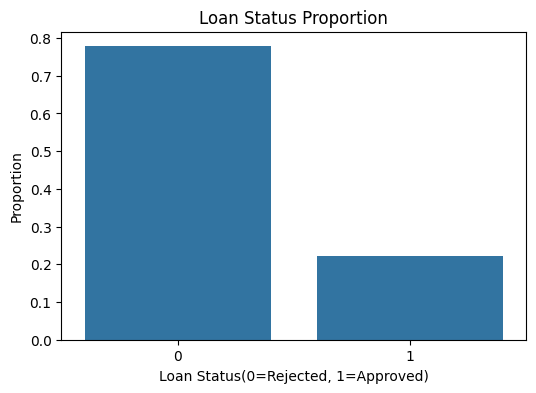

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x=loan_dist.index, y=loan_dist.values)
plt.title('Loan Status Proportion')
plt.ylabel('Proportion')
plt.xlabel('Loan Status(0=Rejected, 1=Approved)')
plt.show()

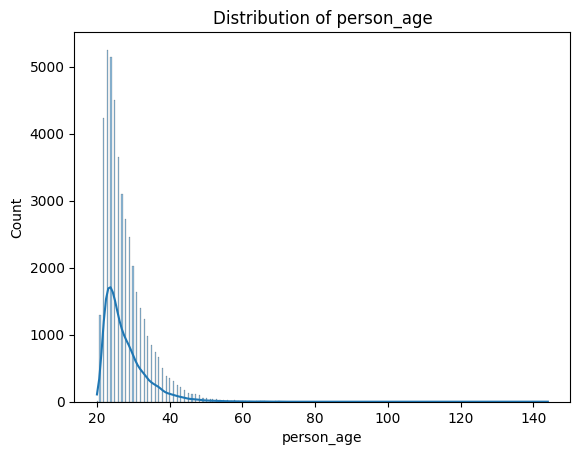

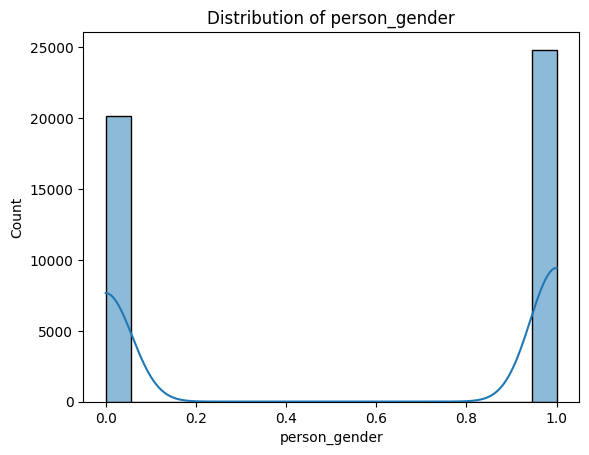

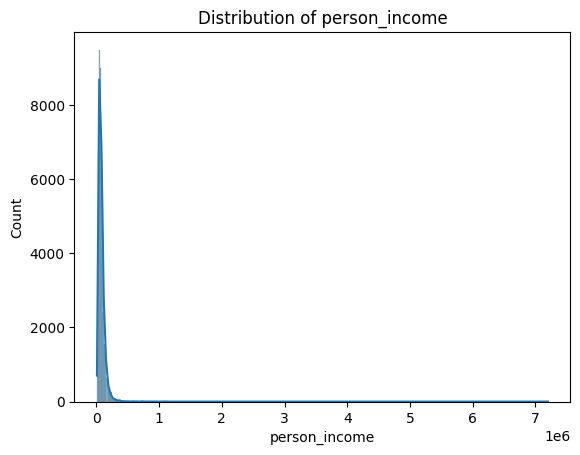

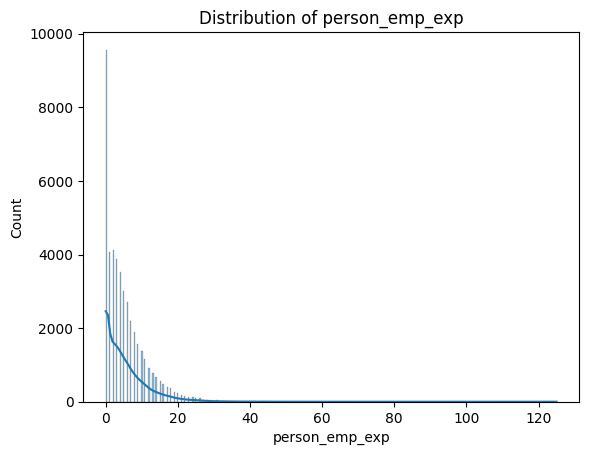

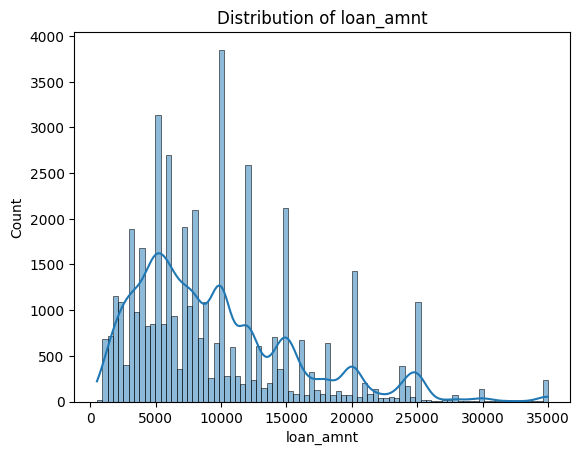

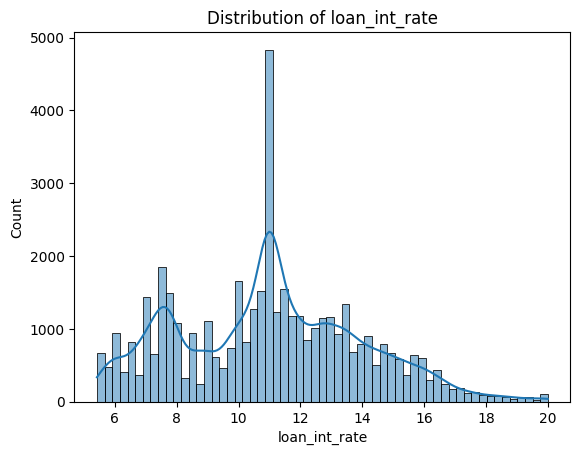

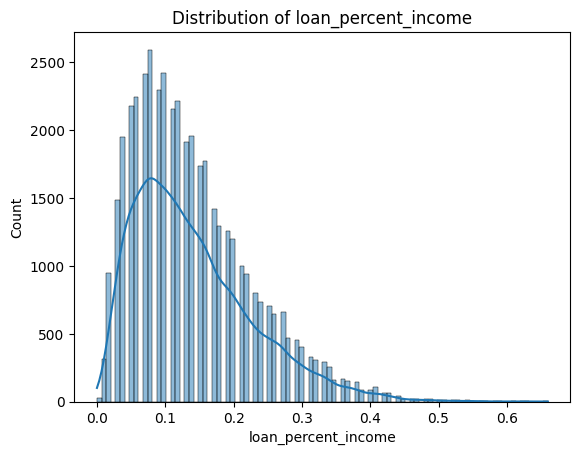

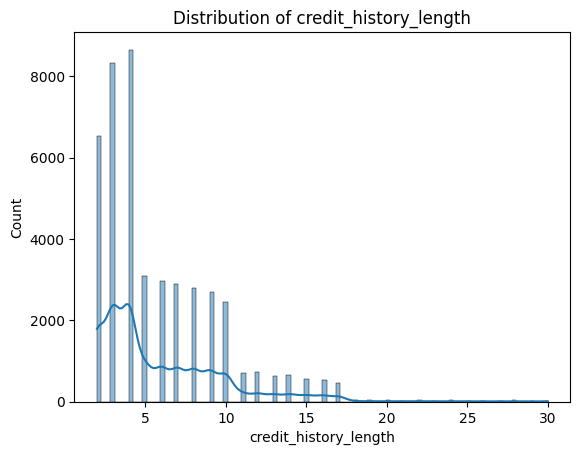

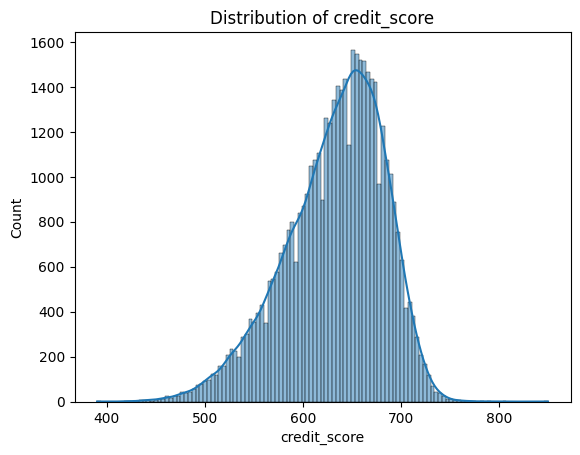

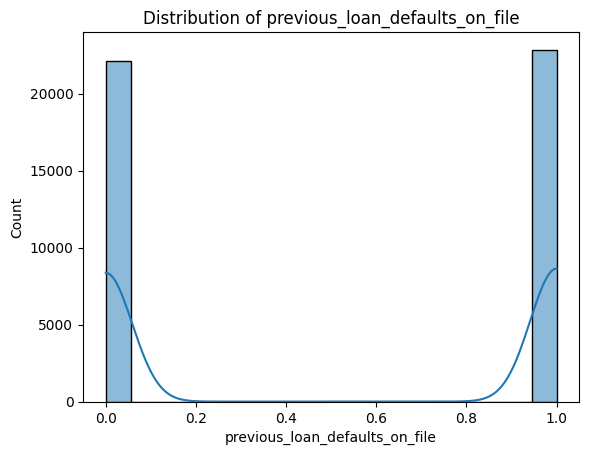

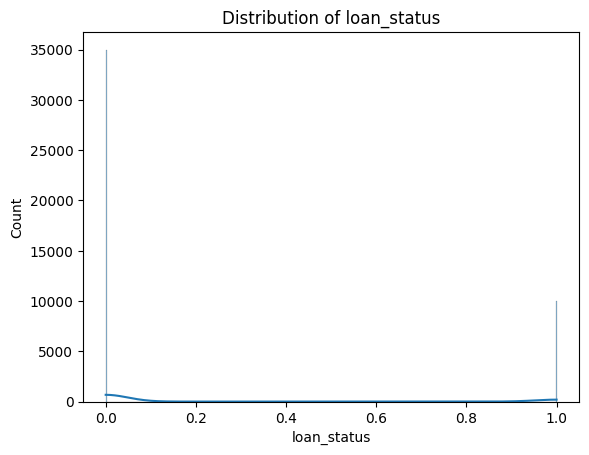

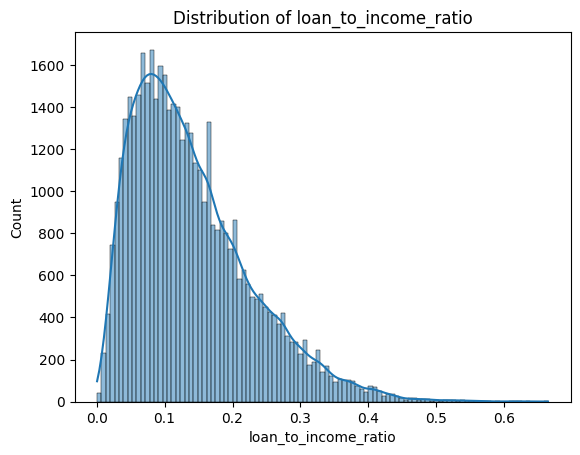

In [26]:
num_cols = df.select_dtypes(include=['int64','float64'])

for cols in num_cols:
    plt.figure()
    sns.histplot(x=df[cols], kde=True)
    plt.title(f"Distribution of {cols}")
    plt.show()

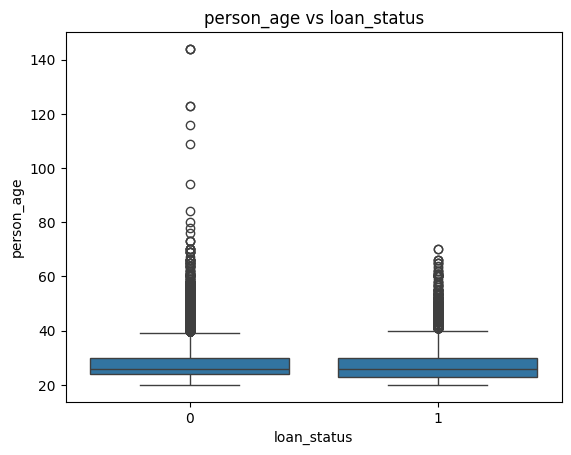

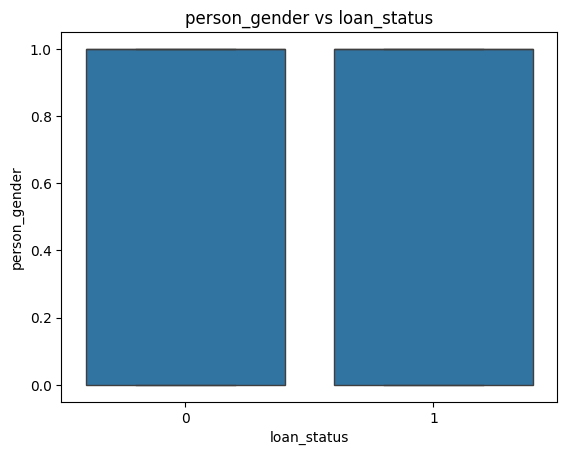

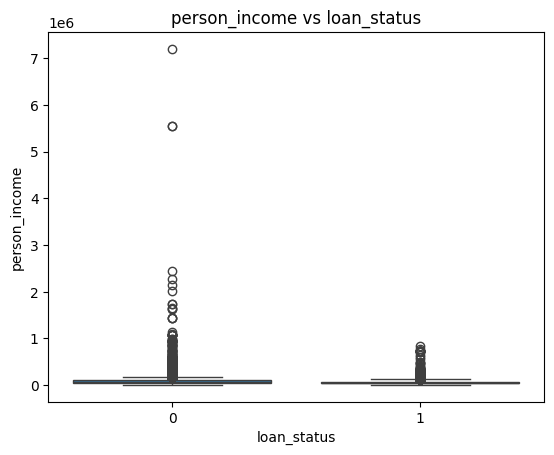

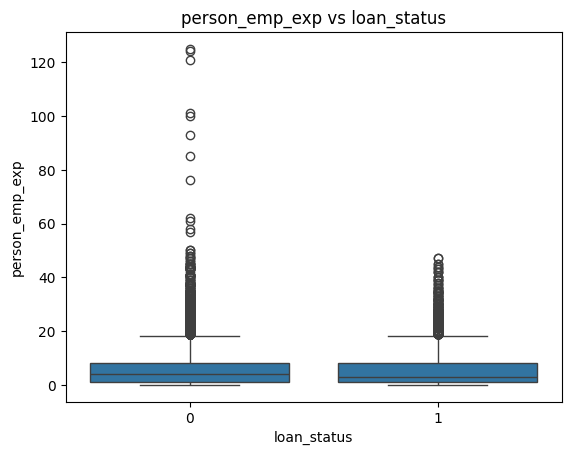

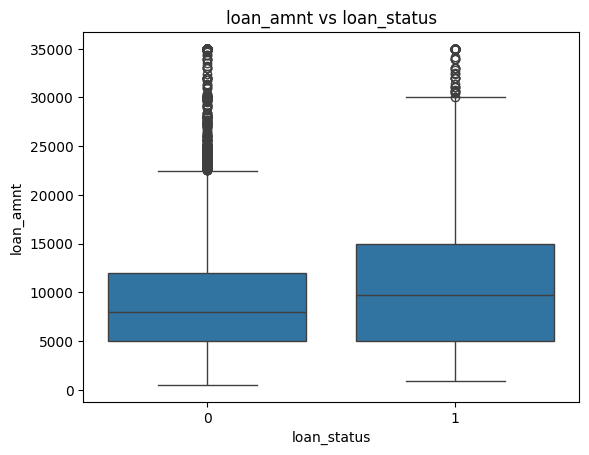

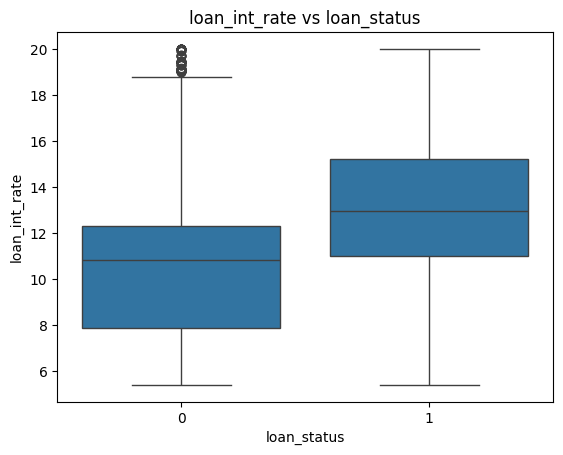

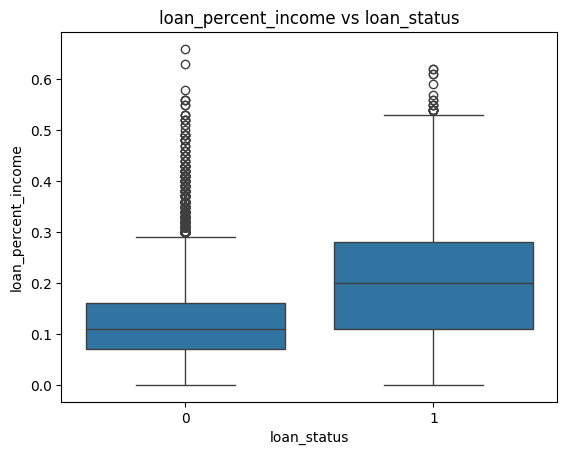

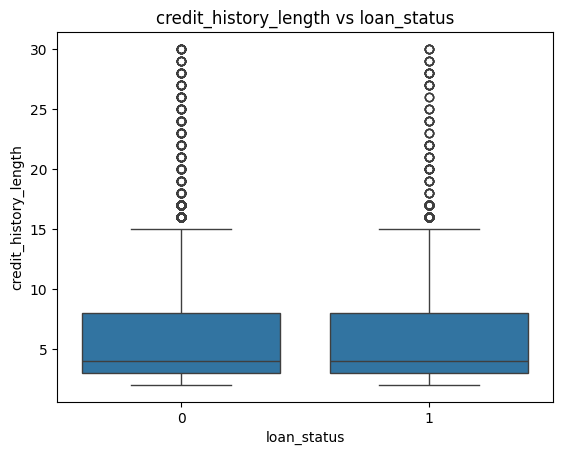

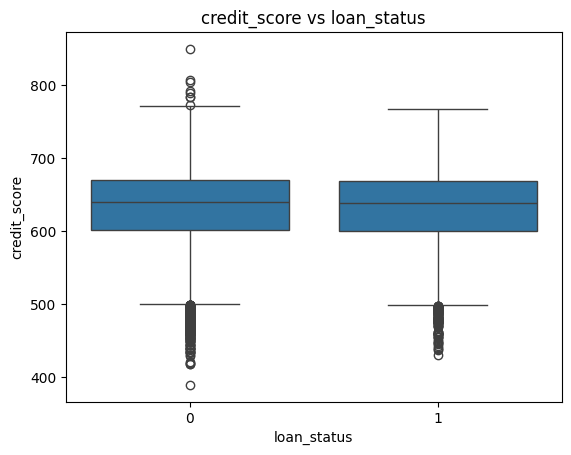

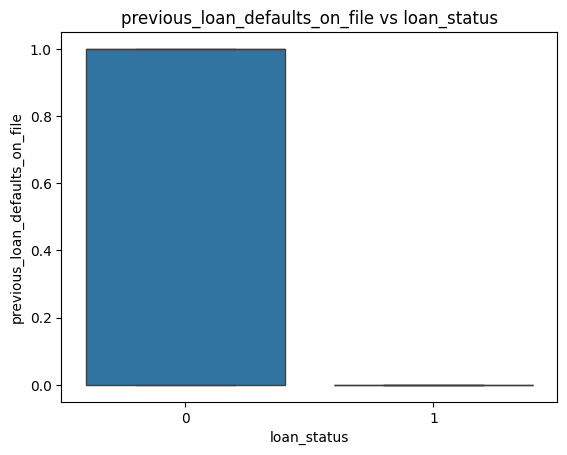

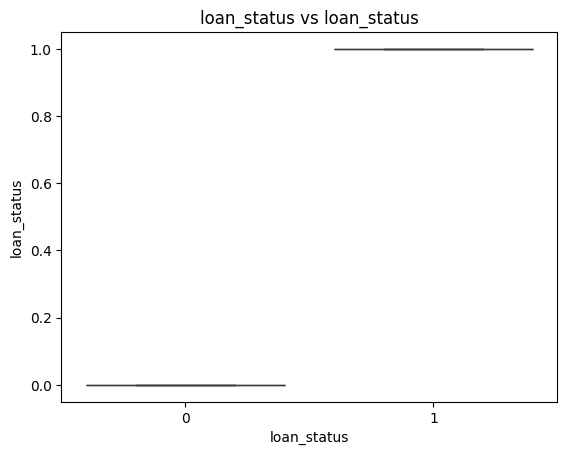

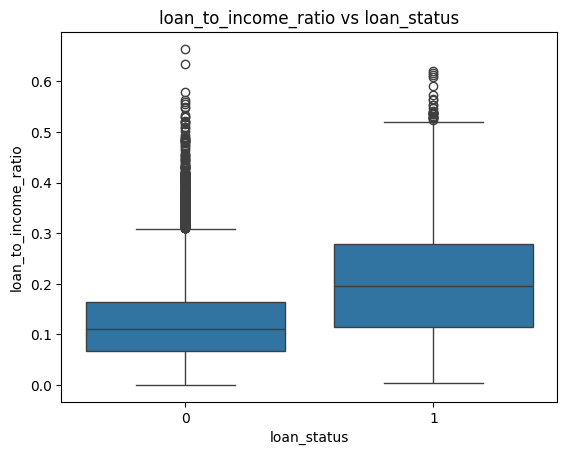

In [27]:
for cols in num_cols:
    plt.figure()
    sns.boxplot(x='loan_status', y=cols, data=df)
    plt.title(f'{cols} vs loan_status')
    plt.show()

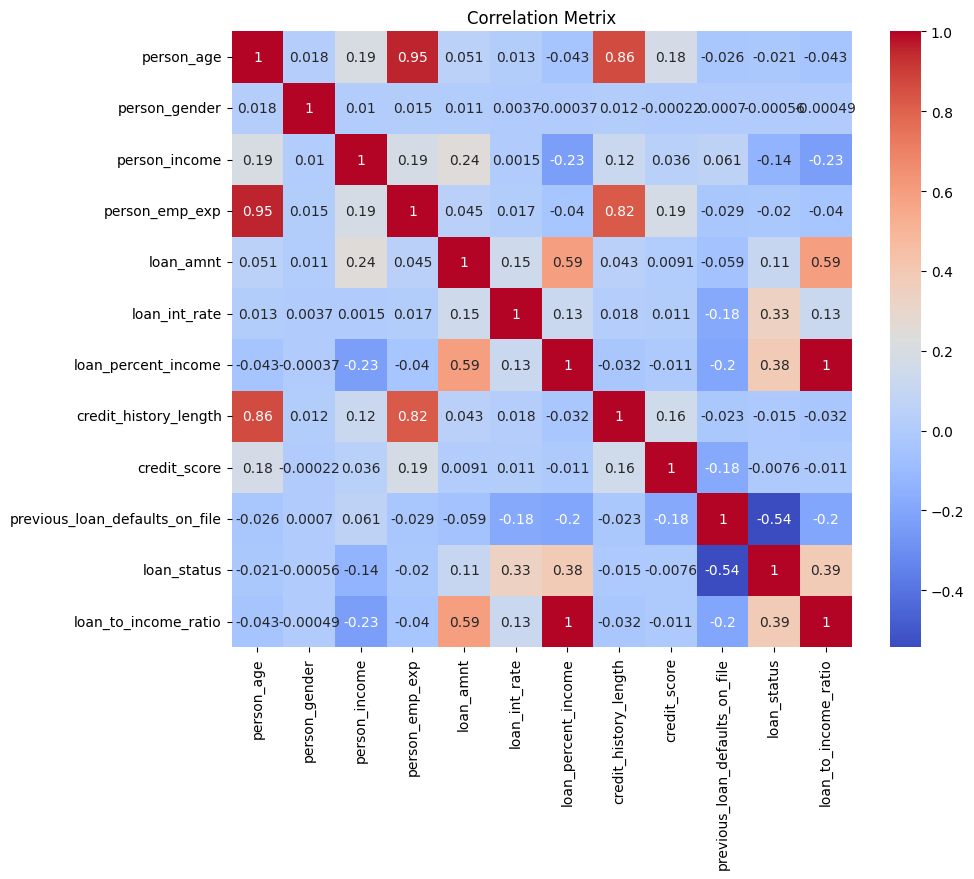

In [28]:
nums_cols = df.select_dtypes(include=['number']).columns
corr = df[nums_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Metrix')
plt.show()

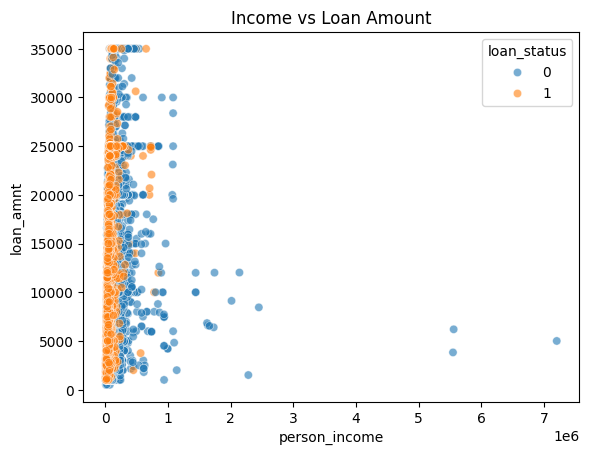

In [29]:
sns.scatterplot(data=df , x='person_income', y='loan_amnt', hue='loan_status', alpha=0.6)
plt.title('Income vs Loan Amount')
plt.show()

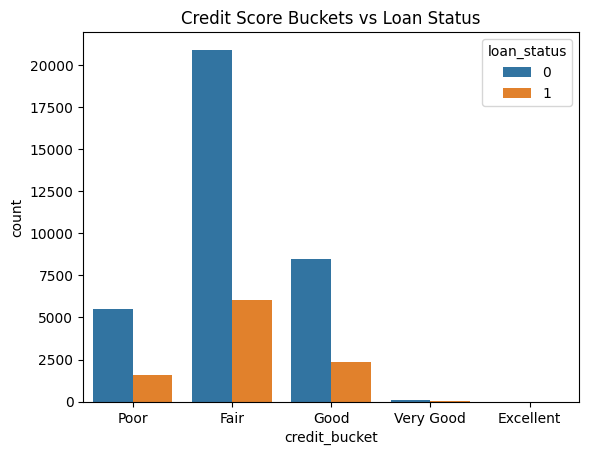

In [30]:
df['credit_bucket'] = pd.cut(
    df['credit_score'],
    bins=[300,580,670,740,800,850],
    labels=['Poor','Fair','Good','Very Good','Excellent']
)

sns.countplot(x='credit_bucket', hue='loan_status', data=df)
plt.title("Credit Score Buckets vs Loan Status")
plt.show()

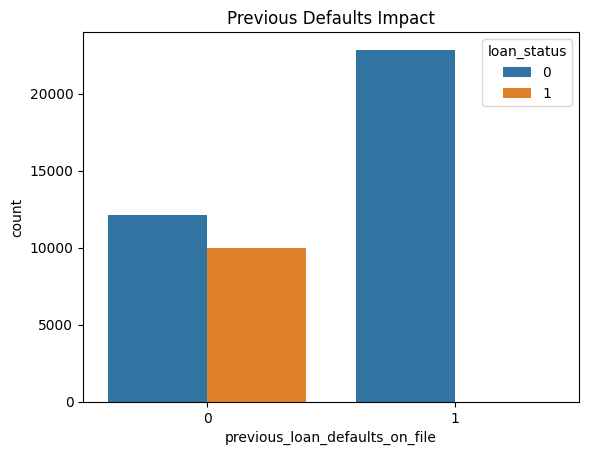

In [31]:
sns.countplot(
    x='previous_loan_defaults_on_file',
    hue='loan_status',
    data=df
)
plt.title("Previous Defaults Impact")
plt.show()

In [32]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [33]:
df.sample(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_history_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_to_income_ratio,age_group,income_group,credit_category,credit_bucket
44934,29,0,Master,53753.0,5,RENT,4000.0,HOMEIMPROVEMENT,12.51,0.07,8.0,614,0,1,0.074414,26-35,Medium(30-60k),Fair,Fair
29596,40,0,High School,26927.0,16,RENT,3000.0,HOMEIMPROVEMENT,14.09,0.11,13.0,508,0,1,0.111412,36-45,Low(<30k),Poor,Poor
11024,22,1,Bachelor,67477.0,0,MORTGAGE,7400.0,MEDICAL,14.84,0.11,2.0,688,0,1,0.109667,18-25,High(60-100k),Good,Good
30346,43,0,Bachelor,211614.0,19,RENT,7000.0,HOMEIMPROVEMENT,5.99,0.03,12.0,688,1,0,0.033079,36-45,Very High(>100k),Good,Good
22056,29,1,Bachelor,63620.0,9,OWN,16000.0,VENTURE,10.99,0.25,8.0,594,1,0,0.251493,26-35,High(60-100k),Fair,Fair
33789,26,1,Bachelor,126462.0,2,RENT,12000.0,PERSONAL,12.48,0.09,3.0,664,0,0,0.094890,26-35,Very High(>100k),Fair,Fair
20731,32,1,Master,45402.0,8,RENT,5000.0,VENTURE,12.53,0.11,9.0,630,1,0,0.110127,26-35,Medium(30-60k),Fair,Fair
3266,25,1,Bachelor,15187.0,4,RENT,3600.0,DEBTCONSOLIDATION,9.62,0.24,2.0,620,0,1,0.237045,18-25,Low(<30k),Fair,Fair
13039,24,1,High School,44310.0,1,OWN,12000.0,MEDICAL,11.01,0.27,3.0,627,1,0,0.270819,18-25,Medium(30-60k),Fair,Fair
41706,32,1,High School,78980.0,11,RENT,15000.0,EDUCATION,7.51,0.19,9.0,610,1,0,0.189921,26-35,High(60-100k),Fair,Fair


In [34]:
df.drop(['loan_to_income_ratio','credit_bucket'],axis=1, inplace=True)

# Encoding the columns 

In [36]:
# person_education -> ordinal encoding 

order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
encoder = OrdinalEncoder(categories=order)
df['person_education'] = encoder.fit_transform(df[['person_education']])

In [37]:
# person_home_ownership & loan_intent -> onehot encoding

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True, dtype=int)

In [38]:
# age_group -> ordinal encoding 

order = [['18-25', '26-35', '36-45', '46-60', '60+']]
encoder = OrdinalEncoder(categories=order)
df['age_group'] = encoder.fit_transform(df[['age_group']])

In [39]:
# income_group -> ordinal encoding

order = [['Low(<30k)', 'Medium(30-60k)', 'High(60-100k)', 'Very High(>100k)']]
encoder = OrdinalEncoder(categories=order)
df['income_group'] = encoder.fit_transform(df[['income_group']])

In [40]:
# credit_category -> ordinal encoding

order = [['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']]
encoder = OrdinalEncoder(categories=order)
df['credit_category'] = encoder.fit_transform(df[['credit_category']])

# Feature Matrix and Target Vector extraction

In [41]:
X = df.copy()
X = X.drop('loan_status', axis=1)
print(X.shape)

(45000, 22)


In [42]:
y = df.loc[:,'loan_status'].values

In [43]:

# split 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36000, 22)
(9000, 22)
(36000,)
(9000,)


<class 'pandas.DataFrame'>
Index: 36000 entries, 6048 to 44095
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      36000 non-null  int64  
 1   person_gender                   36000 non-null  int64  
 2   person_education                36000 non-null  float64
 3   person_income                   36000 non-null  float64
 4   person_emp_exp                  36000 non-null  int64  
 5   loan_amnt                       36000 non-null  float64
 6   loan_int_rate                   36000 non-null  float64
 7   loan_percent_income             36000 non-null  float64
 8   credit_history_length           36000 non-null  float64
 9   credit_score                    36000 non-null  int64  
 10  previous_loan_defaults_on_file  36000 non-null  int64  
 11  age_group                       36000 non-null  float64
 12  income_group                    36000 non-nul